In [34]:
import pandas as pd

df = pd.read_csv('student_habits_performance.csv')

print("First 5 rows")
print(df.head())

First 5 rows
  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master      

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str    
 13  

In [36]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [37]:
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


In [38]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

print("Correlation with Exam Score")
print(corr_matrix['exam_score'].sort_values(ascending=False))

Correlation with Exam Score
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


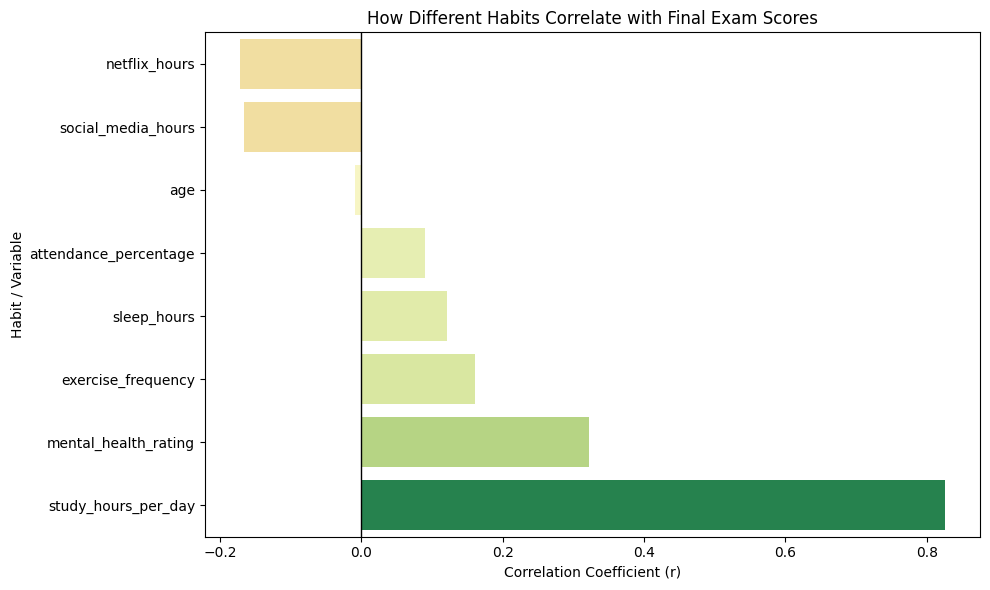

In [58]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

exam_corr = corr_matrix['exam_score'].drop('exam_score').sort_values()

plt.figure(figsize=(10, 6))

norm = mcolors.Normalize(vmin=-1, vmax=1)
cmap = plt.get_cmap('RdYlGn')
my_gradient_colors = [cmap(norm(val)) for val in exam_corr.values]

sns.barplot(x=exam_corr.values, y=exam_corr.index, hue=exam_corr.index, palette=my_gradient_colors, legend=False)

plt.title('How Different Habits Correlate with Final Exam Scores')
plt.xlabel('Correlation Coefficient (r)')
plt.ylabel('Habit / Variable')

plt.axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

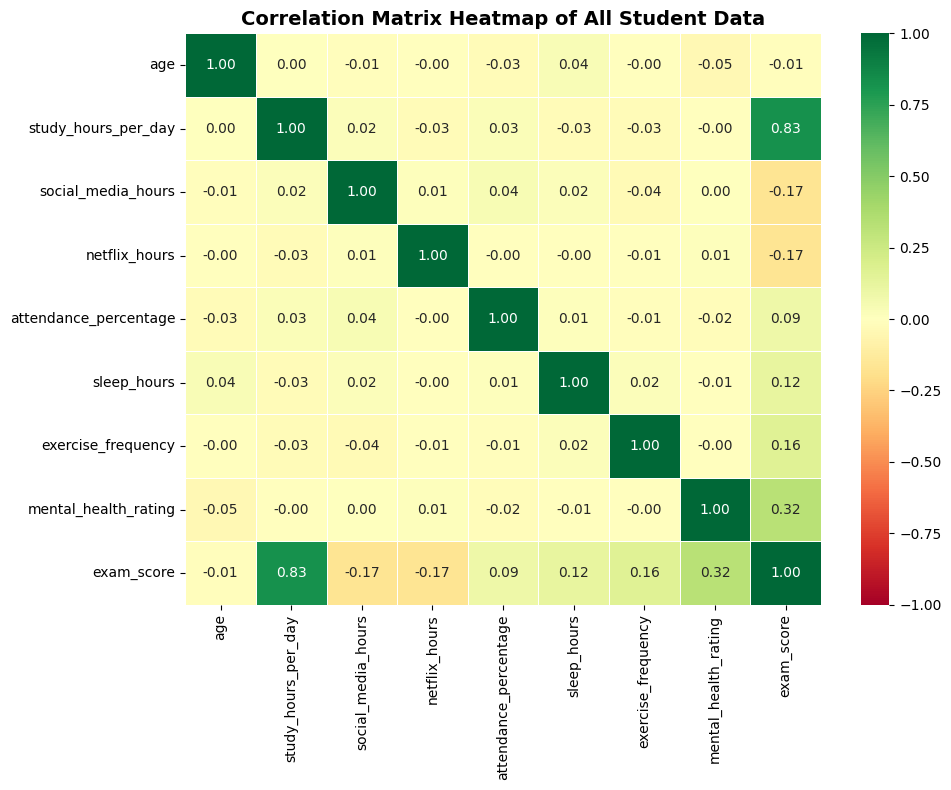

In [59]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt=".2f", 
            linewidths=0.5, linecolor='white')

plt.title('Correlation Matrix Heatmap of All Student Data', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

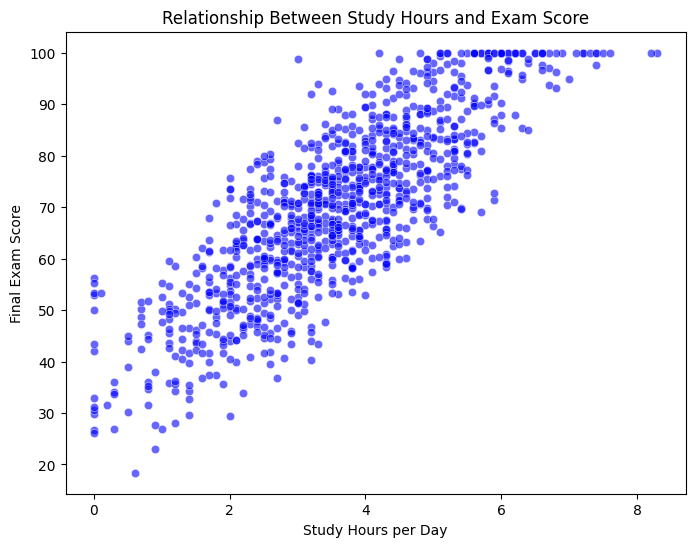

In [63]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x='study_hours_per_day', y='exam_score', data=df, color='blue', alpha=0.6)

plt.title('Relationship Between Study Hours and Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Final Exam Score')

plt.show()

In [55]:
median_study = df['study_hours_per_day'].median()

df['study_group'] = df['study_hours_per_day'].apply(lambda x: 'High Study' if x >= median_study else 'Low Study')

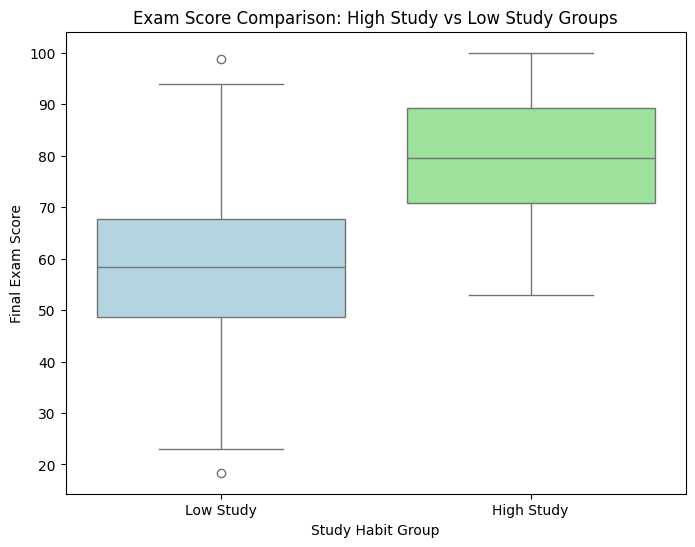

In [56]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='study_group', y='exam_score', data=df, 
            hue='study_group', palette={'High Study': 'lightgreen', 'Low Study': 'lightblue'})

plt.title('Exam Score Comparison: High Study vs Low Study Groups')
plt.xlabel('Study Habit Group')
plt.ylabel('Final Exam Score')

plt.show()

In [57]:
from scipy import stats

high_study_scores = df[df['study_group'] == 'High Study']['exam_score']
low_study_scores = df[df['study_group'] == 'Low Study']['exam_score']

t_stat, p_val = stats.ttest_ind(high_study_scores, low_study_scores)

print("T-Test Results")
print(f"High Study Average Score: {high_study_scores.mean():.2f}")
print(f"Low Study Average Score: {low_study_scores.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val}")

T-Test Results
High Study Average Score: 80.10
Low Study Average Score: 57.81
T-statistic: 27.7087
P-value: 8.475931183227391e-126
